<a href="https://colab.research.google.com/github/arunpr2313/24ADI006_24BAD012/blob/main/Arun%20PR_24BAD012_EX7_GAN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arun PR 24BAD012
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train set : (60000, 28, 28) | labels: (60000,)
Test set  : (10000, 28, 28) | labels: (10000,)
Image size: 28 x 28 (grayscale) | dtype: uint8
Pixel range before scaling: 0 - 255
      class  train images  test images
T-shirt/top          6000         1000
    Trouser          6000         1000
   Pullover          6000         1000
      Dress          6000         1000
       Coat          6000         1000
     Sandal          6000         1000
      Shirt          6000         1000
    Sneaker          6000         1000
        Bag          6000         1000
 Ankle boot          6000         1000


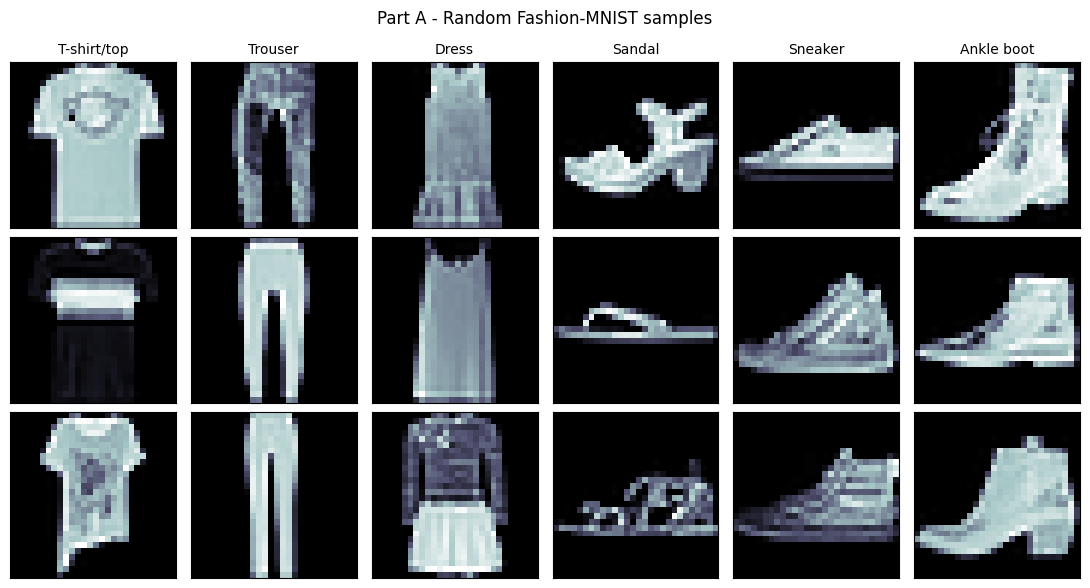

Scaled range: -1.0 to 1.0 | new shape: (60000, 28, 28, 1)
Pipeline element spec: TensorSpec(shape=(256, 28, 28, 1), dtype=tf.float32, name=None)
Steps per epoch: 234


In [1]:
print("Arun PR 24BAD012")
# Part A
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tensorflow as tf
import keras
from keras import layers

print("GPU available:", tf.config.list_physical_devices("GPU"))   # should list a GPU on Colab T4
tf.random.set_seed(35)
np.random.seed(35)

# Load the Fashion-MNIST clothing dataset
(train_x, train_y), (test_x, test_y) = keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Explore the dataset: number of images, dimensions, pixel range
print("Train set :", train_x.shape, "| labels:", train_y.shape)
print("Test set  :", test_x.shape, "| labels:", test_y.shape)
print("Image size:", train_x.shape[1], "x", train_x.shape[2], "(grayscale) | dtype:", train_x.dtype)
print("Pixel range before scaling:", int(train_x.min()), "-", int(train_x.max()))
summary_table = pd.DataFrame({"class": class_names,
                              "train images": np.bincount(train_y),
                              "test images": np.bincount(test_y)})
print(summary_table.to_string(index=False))

# Display sample images from the dataset (three random examples of each of six classes)
fig, axs = plt.subplots(3, 6, figsize=(11, 6))
for col, cls in enumerate([0, 1, 3, 5, 7, 9]):
    idx = np.random.choice(np.where(train_y == cls)[0], 3, replace=False)
    for row in range(3):
        axs[row, col].imshow(train_x[idx[row]], cmap="bone")
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
        if row == 0:
            axs[row, col].set_title(class_names[cls], fontsize=10)
fig.suptitle("Part A - Random Fashion-MNIST samples", fontsize=12)
plt.tight_layout()
plt.show()

# Normalize pixel values to [-1, 1] and reshape to (N, 28, 28, 1)
train_imgs = (train_x.astype("float32") / 255.0) * 2.0 - 1.0
train_imgs = np.expand_dims(train_imgs, axis=-1)
print("Scaled range:", train_imgs.min(), "to", train_imgs.max(), "| new shape:", train_imgs.shape)

# Data pipeline for batch-wise training
BATCH = 256
train_ds = (tf.data.Dataset.from_tensor_slices(train_imgs)
            .cache()
            .shuffle(10_000, seed=35)
            .batch(BATCH, drop_remainder=True)
            .prefetch(buffer_size=2))
print("Pipeline element spec:", train_ds.element_spec)
print("Steps per epoch:", train_ds.cardinality().numpy())


Arun PR 24BAD012
Noise vector shape: (1, 128) -> generated image shape: (1, 28, 28, 1)


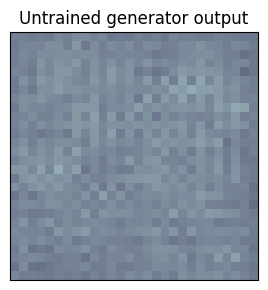

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise (InputLayer)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ project (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 16)     │         8,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image (Conv2D)                  │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,809 (1.65 MB)

 Trainable params: 431,585 (1.65 MB)

 Non-trainable params: 224 (896.00 B)

In [2]:
print("Arun PR 24BAD012")
# Part B
LATENT_DIM = 128                                   # size of the random noise vector

def make_generator(latent_dim=LATENT_DIM):
    z = keras.Input(shape=(latent_dim,), name="noise")                     # noise input
    x = layers.Dense(7 * 7 * 64, name="project")(z)                       # Dense layer
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.UpSampling2D()(x)                                           # 14 x 14
    x = layers.Conv2D(32, 3, padding="same")(x)                           # convolution
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(16, 4, strides=2, padding="same")(x)        # 28 x 28 (transposed conv)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    out = layers.Conv2D(1, 3, padding="same", activation="tanh", name="image")(x)   # tanh -> [-1, 1]
    return keras.Model(z, out, name="generator")

G = make_generator()

# Generate an image from a random noise vector before any training
z0 = tf.random.normal((1, LATENT_DIM))
img0 = G(z0, training=False)
print("Noise vector shape:", z0.shape, "-> generated image shape:", img0.shape)

fig, ax = plt.subplots(figsize=(3.2, 3.4))
ax.imshow(img0[0, :, :, 0], cmap="bone", vmin=-1, vmax=1)
ax.set_title("Untrained generator output")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

# Show the generator's layer-by-layer summary
G.summary()


In [3]:
print("Arun PR 24BAD012")
# Part C
def make_discriminator():
    inp = keras.Input(shape=(28, 28, 1), name="image")
    x = layers.Conv2D(32, 4, strides=2, padding="same")(inp)               # 14 x 14
    x = layers.LeakyReLU(0.25)(x)
    x = layers.Conv2D(64, 4, strides=2, padding="same")(x)                # 7 x 7
    x = layers.LeakyReLU(0.25)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)                # 4 x 4
    x = layers.LeakyReLU(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid", name="real_or_fake")(x)    # binary output
    return keras.Model(inp, out, name="discriminator")

D = make_discriminator()

# Compile the Discriminator with Adam and binary cross-entropy
D.compile(optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
          loss=keras.losses.BinaryCrossentropy())

# Combine Generator and Discriminator into one GAN model
class GAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim, **kw):
        super().__init__(**kw)
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.d_tracker = keras.metrics.Mean(name="d_loss")
        self.g_tracker = keras.metrics.Mean(name="g_loss")

    def compile(self, g_opt, d_opt, loss_fn, **kw):
        super().compile(**kw)
        self.g_opt, self.d_opt, self.loss_fn = g_opt, d_opt, loss_fn

    @property
    def metrics(self):
        return [self.d_tracker, self.g_tracker]

    def train_step(self, real_batch):
        n = tf.shape(real_batch)[0]

        # (1) Train the Discriminator: real images -> 1 (smoothed to 0.9), generated images -> 0
        fake_batch = self.generator(tf.random.normal((n, self.latent_dim)), training=True)
        with tf.GradientTape() as tape:
            p_real = self.discriminator(real_batch, training=True)
            p_fake = self.discriminator(fake_batch, training=True)
            d_loss = (self.loss_fn(tf.fill((n, 1), 0.9), p_real) +
                      self.loss_fn(tf.zeros((n, 1)), p_fake))
        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply(grads, self.discriminator.trainable_variables)

        # (2) Train the Generator through the combined model (Discriminator weights untouched)
        with tf.GradientTape() as tape:
            made = self.generator(tf.random.normal((n, self.latent_dim)), training=True)
            verdict = self.discriminator(made, training=False)
            g_loss = self.loss_fn(tf.ones((n, 1)), verdict)
        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply(grads, self.generator.trainable_variables)

        self.d_tracker.update_state(d_loss)
        self.g_tracker.update_state(g_loss)
        return {"d_loss": self.d_tracker.result(), "g_loss": self.g_tracker.result()}

gan = GAN(G, D, LATENT_DIM, name="gan")
gan.compile(g_opt=keras.optimizers.Adam(2e-4, beta_1=0.5),
            d_opt=keras.optimizers.Adam(2e-4, beta_1=0.5),
            loss_fn=keras.losses.BinaryCrossentropy())

# Model summaries
print("######## GENERATOR ########")
G.summary()
print("\n######## DISCRIMINATOR ########")
D.summary()
print("\nGAN = Generator + Discriminator")
print("Generator parameters    :", f"{G.count_params():,}")
print("Discriminator parameters:", f"{D.count_params():,}")
print("Discriminator output for the untrained image (1 = real):", round(float(D(img0, training=False)[0, 0]), 4))


Arun PR 24BAD012
######## GENERATOR ########


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise (InputLayer)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ project (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 16)     │         8,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image (Conv2D)                  │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,809 (1.65 MB)

 Trainable params: 431,585 (1.65 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ real_or_fake (Dense)            │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,329 (278.63 KB)

 Trainable params: 71,329 (278.63 KB)

 Non-trainable params: 0 (0.00 B)


GAN = Generator + Discriminator
Generator parameters    : 431,809
Discriminator parameters: 71,329
Discriminator output for the untrained image (1 = real): 0.496


Arun PR 24BAD012
Epoch 1/30
   -> snapshot stored at epoch 1
234/234 - 5s - 20ms/step - d_loss: 1.3293 - g_loss: 0.8514
Epoch 2/30
234/234 - 4s - 16ms/step - d_loss: 1.3315 - g_loss: 0.8473
Epoch 3/30
234/234 - 4s - 18ms/step - d_loss: 1.3316 - g_loss: 0.8466
Epoch 4/30
234/234 - 4s - 18ms/step - d_loss: 1.3336 - g_loss: 0.8452
Epoch 5/30
   -> snapshot stored at epoch 5
234/234 - 4s - 16ms/step - d_loss: 1.3393 - g_loss: 0.8438
Epoch 6/30
234/234 - 4s - 16ms/step - d_loss: 1.3407 - g_loss: 0.8379
Epoch 7/30
234/234 - 5s - 20ms/step - d_loss: 1.3422 - g_loss: 0.8357
Epoch 8/30
234/234 - 4s - 16ms/step - d_loss: 1.3434 - g_loss: 0.8377
Epoch 9/30
234/234 - 4s - 16ms/step - d_loss: 1.3433 - g_loss: 0.8353
Epoch 10/30
   -> snapshot stored at epoch 10
234/234 - 4s - 17ms/step - d_loss: 1.3447 - g_loss: 0.8340
Epoch 11/30
234/234 - 4s - 16ms/step - d_loss: 1.3462 - g_loss: 0.8361
Epoch 12/30
234/234 - 4s - 16ms/step - d_loss: 1.3450 - g_loss: 0.8383
Epoch 13/30
234/234 - 4s - 17ms/step - d

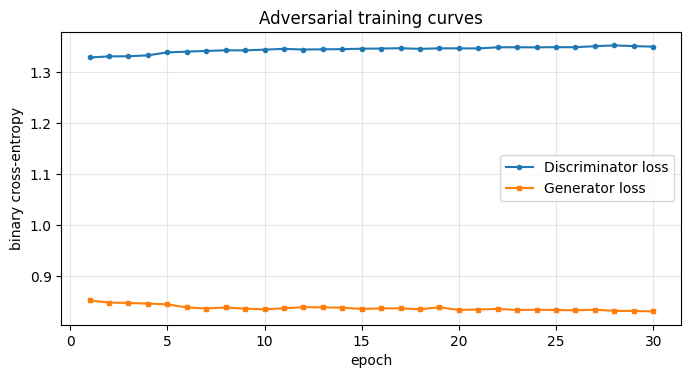

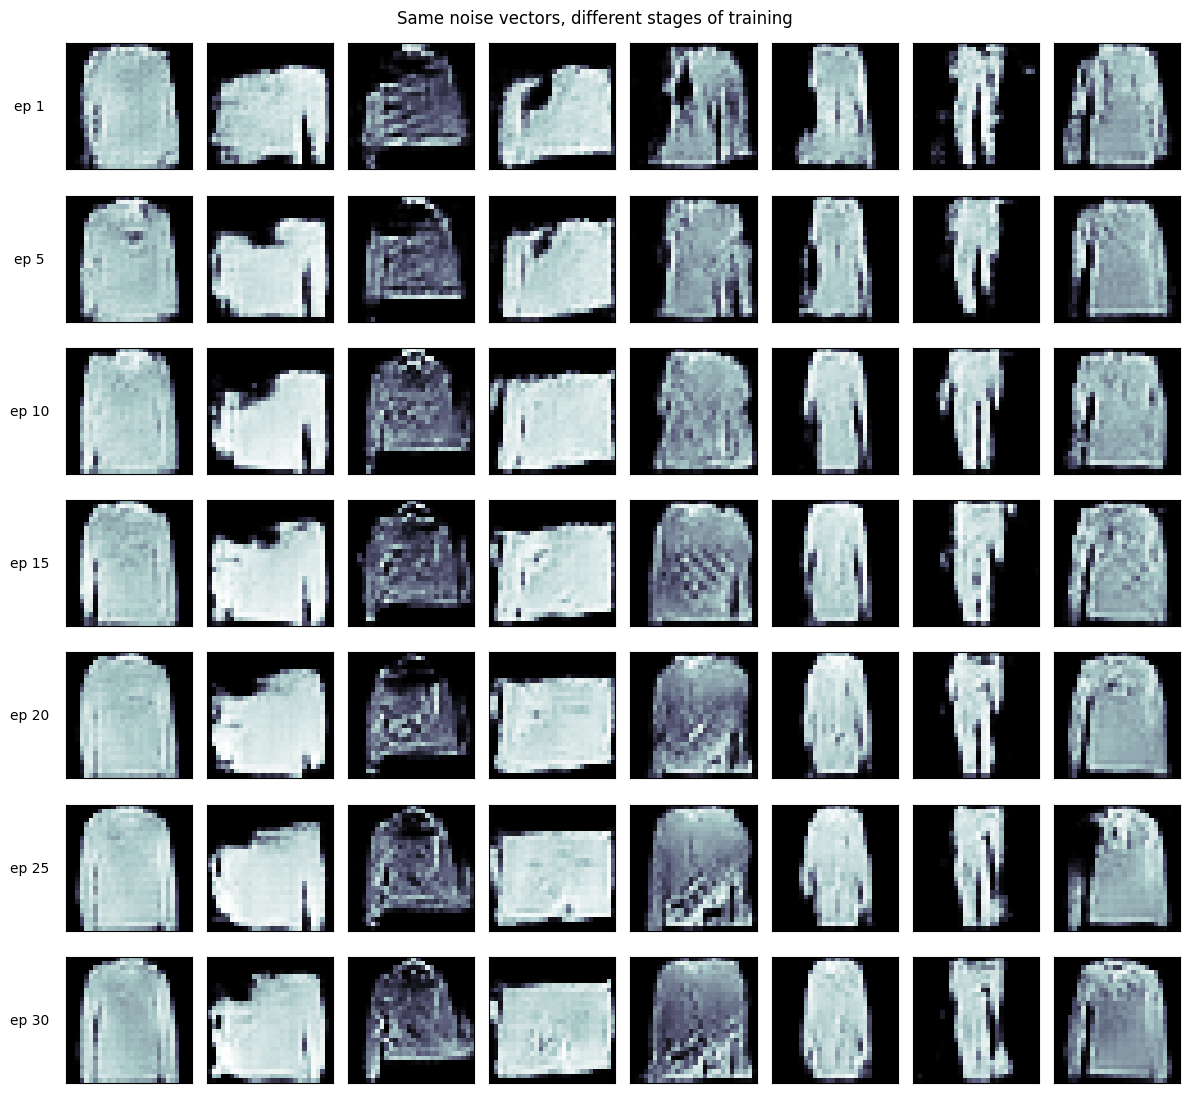

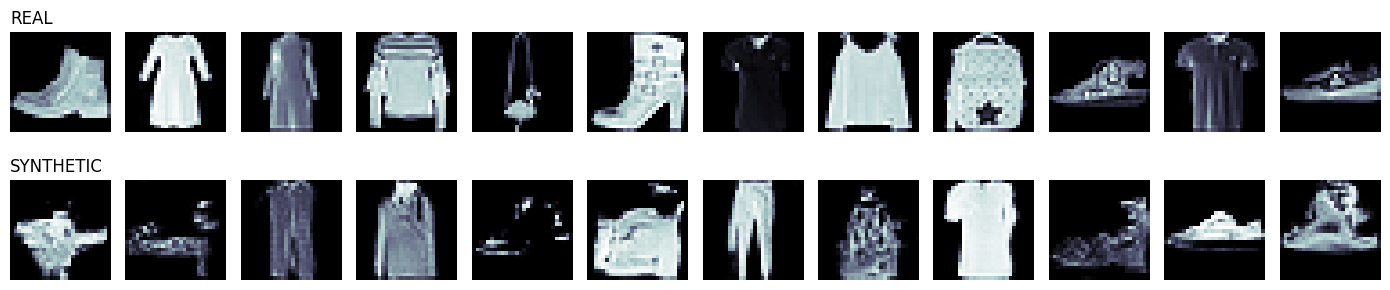

Judge accuracy on real test images: 0.830
      class  % of synthetic images
T-shirt/top                    6.6
    Trouser                   10.2
   Pullover                   11.8
      Dress                   10.4
       Coat                    8.0
     Sandal                    8.6
      Shirt                   13.4
    Sneaker                   12.4
        Bag                    9.6
 Ankle boot                    9.0

Mean classifier confidence on synthetic images: 0.742
Classes represented (>1% of images): 10 / 10


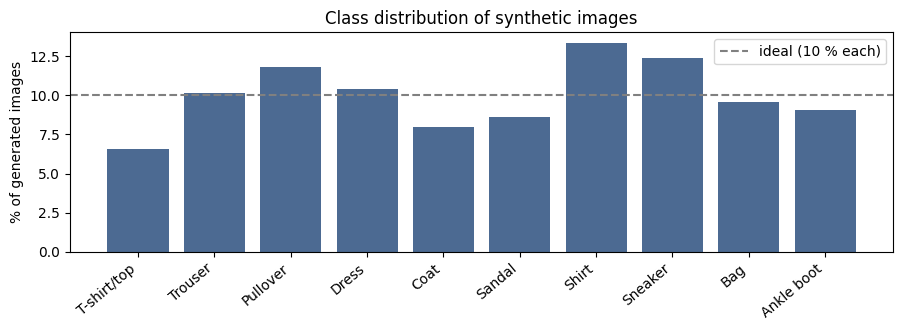

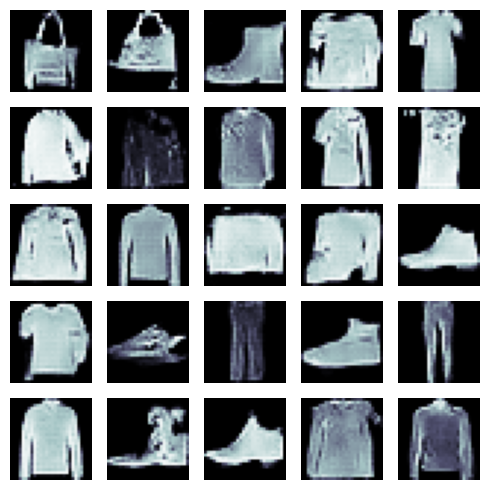

Files written to Arun_gan_outputs : 27


In [5]:
print("Arun PR 24BAD012")
# Part D
EPOCHS = 30
SHOW_EVERY = 5
fixed_z = tf.random.normal((24, LATENT_DIM), seed=35)      # same 24 noise vectors tracked all along
OUT = "Arun_gan_outputs"
os.makedirs(OUT, exist_ok=True)
stage_images = {}

def to_unit(a):
    return (np.asarray(a) + 1.0) / 2.0

class Snapshot(keras.callbacks.Callback):
    # Periodically store synthetic images for the fixed noise vectors
    def on_epoch_end(self, epoch, logs=None):
        ep = epoch + 1
        if ep == 1 or ep % SHOW_EVERY == 0:
            stage_images[ep] = G(fixed_z, training=False).numpy()
            print(f"   -> snapshot stored at epoch {ep}")

# Train: Discriminator on real + synthetic images, Generator through the GAN; losses are recorded
history = gan.fit(train_ds, epochs=EPOCHS, callbacks=[Snapshot()], verbose=2)
g_hist = history.history["g_loss"]
d_hist = history.history["d_loss"]

# Generator loss and Discriminator loss over the epochs
plt.figure(figsize=(8, 3.8))
plt.plot(np.arange(1, EPOCHS + 1), d_hist, "o-", ms=3, label="Discriminator loss")
plt.plot(np.arange(1, EPOCHS + 1), g_hist, "s-", ms=3, label="Generator loss")
plt.xlabel("epoch"); plt.ylabel("binary cross-entropy"); plt.legend(); plt.grid(alpha=.3)
plt.title("Adversarial training curves")
plt.show()

# Rows = training stages, columns = the same noise vectors
fig, axs = plt.subplots(len(stage_images), 8, figsize=(12, 1.6 * len(stage_images)))
for r, ep in enumerate(sorted(stage_images)):
    for c in range(8):
        axs[r, c].imshow(to_unit(stage_images[ep][c, :, :, 0]), cmap="bone", vmin=0, vmax=1)
        axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
    axs[r, 0].set_ylabel(f"ep {ep}", rotation=0, labelpad=26, va="center")
fig.suptitle("Same noise vectors, different stages of training")
plt.tight_layout()
plt.show()

# Top row: real clothes, bottom row: GAN output
fresh = G(tf.random.normal((12, LATENT_DIM)), training=False).numpy()
pick = np.random.choice(len(train_x), 12, replace=False)
fig, axs = plt.subplots(2, 12, figsize=(14, 3.3))
for i in range(12):
    axs[0, i].imshow(train_x[pick[i]], cmap="bone"); axs[0, i].axis("off")
    axs[1, i].imshow(to_unit(fresh[i, :, :, 0]), cmap="bone", vmin=0, vmax=1); axs[1, i].axis("off")
axs[0, 0].set_title("REAL", loc="left"); axs[1, 0].set_title("SYNTHETIC", loc="left")
plt.tight_layout()
plt.show()

# Analyze quality and diversity: a small classifier trained on REAL images labels the synthetic ones
judge = keras.Sequential([
    keras.Input((28, 28, 1)),
    layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(), layers.Dense(10, activation="softmax")])
judge.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
judge.fit(train_imgs, train_y, epochs=2, batch_size=512, verbose=0)
print("Judge accuracy on real test images: %.3f" % judge.evaluate(
    (np.expand_dims(test_x, -1).astype("float32") / 255.0) * 2 - 1, test_y, verbose=0)[1])

many = G(tf.random.normal((3000, LATENT_DIM)), training=False).numpy()
probs = judge.predict(many, verbose=0)
labels = probs.argmax(axis=1)
share = np.bincount(labels, minlength=10) / len(labels) * 100
report = pd.DataFrame({"class": class_names, "% of synthetic images": share.round(1)})
print(report.to_string(index=False))
print("\nMean classifier confidence on synthetic images: %.3f" % probs.max(axis=1).mean())
print("Classes represented (>1%% of images): %d / 10" % (share > 1).sum())

plt.figure(figsize=(9, 3.4))
plt.bar(class_names, share, color="#4c6a92")
plt.axhline(10, ls="--", c="gray", label="ideal (10 % each)")
plt.xticks(rotation=40, ha="right"); plt.ylabel("% of generated images")
plt.title("Class distribution of synthetic images"); plt.legend(); plt.tight_layout()
plt.show()

# Write the final batch of synthetic images and the generator to disk
final = G(tf.random.normal((25, LATENT_DIM)), training=False).numpy()
for i, im in enumerate(final):
    plt.imsave(f"{OUT}/synthetic_{i:02d}.png", to_unit(im[:, :, 0]), cmap="bone", vmin=0, vmax=1)
fig, axs = plt.subplots(5, 5, figsize=(5, 5))
for ax, im in zip(axs.flat, final):
    ax.imshow(to_unit(im[:, :, 0]), cmap="bone", vmin=0, vmax=1); ax.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT}/synthetic_grid.png", dpi=130); plt.show()
G.save(f"{OUT}/generator.keras")
print("Files written to", OUT, ":", len(os.listdir(OUT)))
